In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

random.seed(64)
np.random.seed(64)


In [2]:
def reduce_memory_usage(df):
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != 'object':
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    pass
        else:
            df[col] = df[col].astype('category')
    
    return df


In [3]:
train=pd.read_csv('../input/tabular-playground-series-dec-2021/train.csv')
test=pd.read_csv('../input/tabular-playground-series-dec-2021/test.csv')
reduce_memory_usage(train)
reduce_memory_usage(test);


In [4]:
print("dimensions of train: {}".format(train.shape))
print("dimensions of test: {}".format(test.shape))


dimensions of train: (3600000, 56)
dimensions of test: (400000, 55)


In [5]:
train.describe()


,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,...,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06,3.600000e+06
mean,2.000069e+06,2.980147e+03,1.515727e+02,1.510050e+01,2.712761e+02,5.166790e+01,1.766483e+03,2.118390e+02,2.210576e+02,1.408136e+02,...,3.746250e-02,3.785972e-02,1.201639e-02,1.604194e-02,1.068556e-02,1.219861e-02,4.074917e-02,3.924222e-02,3.158944e-02,1.771544e+00
std,1.154820e+06,2.890440e+02,1.099497e+02,8.546351e+00,2.265100e+02,6.822503e+01,1.315661e+03,3.075498e+01,2.223373e+01,4.367894e+01,...,1.898923e-01,1.908569e-01,1.089587e-01,1.256368e-01,1.028172e-01,1.097716e-01,1.977086e-01,1.941708e-01,1.749044e-01,8.940261e-01
min,0.000000e+00,1.773000e+03,-3.300000e+01,-3.000000e+00,-8.200000e+01,-3.170000e+02,-2.870000e+02,-4.000000e+00,4.900000e+01,-5.300000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.997378e+05,2.760000e+03,6.000000e+01,9.000000e+00,1.100000e+02,4.000000e+00,8.220000e+02,1.980000e+02,2.100000e+02,1.150000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.000172e+06,2.966000e+03,1.230000e+02,1.400000e+01,2.130000e+02,3.100000e+01,1.436000e+03,2.180000e+02,2.240000e+02,1.420000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
75%,3.000448e+06,3.217000e+03,2.470000e+02,2.000000e+01,3.610000e+02,7.800000e+01,2.365000e+03,2.330000e+02,2.370000e+02,1.690000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
max,3.999999e+06,4.383000e+03,4.050000e+02,6.400000e+01,1.602000e+03,6.320000e+02,7.666000e+03,2.970000e+02,2.790000e+02,2.720000e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+00


In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 56 columns):
 #   Column                              Dtype
---  ------                              -----
 0   Id                                  int32
 1   Elevation                           int16
 2   Aspect                              int16
 3   Slope                               int8 
 4   Horizontal_Distance_To_Hydrology    int16
 5   Vertical_Distance_To_Hydrology      int16
 6   Horizontal_Distance_To_Roadways     int16
 7   Hillshade_9am                       int16
 8   Hillshade_Noon                      int16
 9   Hillshade_3pm                       int16
 10  Horizontal_Distance_To_Fire_Points  int16
 11  Wilderness_Area1                    int8 
 12  Wilderness_Area2                    int8 
 13  Wilderness_Area3                    int8 
 14  Wilderness_Area4                    int8 
 15  Soil_Type1                          int8 
 16  Soil_Type2                          

In [7]:
train.head()


,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,3440475,2634,132,3,166,38,1247,251,210,119,...,0,0,0,0,0,0,0,0,0,2
1,2470812,2769,89,5,633,10,626,177,209,178,...,0,0,0,0,0,0,0,0,0,2
2,536780,2749,46,30,127,239,2569,206,216,144,...,0,0,0,0,0,0,0,0,0,2
3,3115135,2574,155,20,279,1,1932,205,189,199,...,0,0,0,0,0,0,0,0,0,2
4,81861,2779,91,19,523,-2,2976,240,246,105,...,0,0,0,0,0,0,0,0,0,2


In [8]:
print(train.isnull().sum())


Id                                    0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0


<Axes: xlabel='Cover_Type', ylabel='count'>

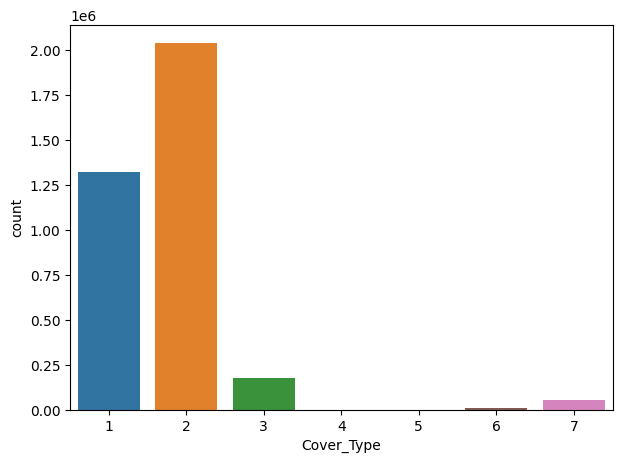

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x='Cover_Type', data=train)


In [10]:
train['Cover_Type'].value_counts(ascending=False)


Cover_Type
2    2036254
1    1320866
3     176184
7      56125
6      10237
4        333
5          1
Name: count, dtype: int64

In [11]:
x = train.drop(columns=['Id','Cover_Type'])
y = train['Cover_Type']


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=123, shuffle =True)


In [13]:
test_df = test.drop(columns=['Id'])


In [14]:
from xgboost import XGBClassifier

params = {
            'objective' : 'multi:softmax',
            'tree_method': 'gpu_hist',
            'eval_metric': 'mlogloss',
            'booster' : 'gbtree',
            'gamma' : 0.75,
            'max_depth': 7,
            'alpha': 10,
            'learning_rate': .007,
            'n_estimators':2000,
            'predictor': 'gpu_predictor'
        }         
           
          

xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train,
          early_stopping_rounds=200,
          eval_set=[(X_val,y_val)],
          verbose=True)


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [15]:
y_pred=xgb.predict(X_val)


NotFittedError: need to call fit or load_model beforehand

In [16]:
from sklearn.metrics import accuracy_score
print('Accuracy Score : ',accuracy_score(y_val, y_pred))


NameError: name 'y_pred' is not defined

In [17]:
y_pred = xgb.predict(test_df)


NotFittedError: need to call fit or load_model beforehand

In [18]:
submission = pd.read_csv('../input/tabular-playground-series-dec-2021/sample_submission.csv')
submission['Cover_Type'] = y_pred
submission.to_csv("submission2.csv",index=False)
submission.head()


NameError: name 'y_pred' is not defined

In [19]:
from catboost import CatBoostClassifier
model = CatBoostClassifier( task_type = 'GPU',devices = '0')
model.fit(X_train, y_train)


Learning rate set to 0.32961
0:	learn: 0.7301813	total: 29.9ms	remaining: 29.8s
1:	learn: 0.5614566	total: 48ms	remaining: 24s
2:	learn: 0.4630563	total: 66.5ms	remaining: 22.1s
3:	learn: 0.3871913	total: 84.6ms	remaining: 21.1s
4:	learn: 0.3376645	total: 104ms	remaining: 20.8s
5:	learn: 0.3026133	total: 126ms	remaining: 20.8s
6:	learn: 0.2772485	total: 146ms	remaining: 20.7s
7:	learn: 0.2577403	total: 165ms	remaining: 20.5s
8:	learn: 0.2452002	total: 185ms	remaining: 20.3s
9:	learn: 0.2325219	total: 202ms	remaining: 20s
10:	learn: 0.2230168	total: 222ms	remaining: 20s
11:	learn: 0.2141988	total: 246ms	remaining: 20.3s
12:	learn: 0.2087731	total: 273ms	remaining: 20.8s
13:	learn: 0.2044959	total: 289ms	remaining: 20.4s
14:	learn: 0.1982799	total: 309ms	remaining: 20.3s
15:	learn: 0.1945961	total: 325ms	remaining: 20s
16:	learn: 0.1897565	total: 344ms	remaining: 19.9s
17:	learn: 0.1867521	total: 362ms	remaining: 19.7s
18:	learn: 0.1843498	total: 378ms	remaining: 19.5s
19:	learn: 0.18175

In [20]:
y_pred1=model.predict(X_val)


In [21]:
from sklearn.metrics import accuracy_score
print('Accuracy Score : ',accuracy_score(y_val, y_pred1))


Accuracy Score :  0.9604930555555555


In [22]:
y_pred1 = model.predict(test_df)


In [23]:
submission = pd.read_csv('../input/tabular-playground-series-dec-2021/sample_submission.csv')
submission['Cover_Type'] = y_pred
submission.to_csv("submission1.csv",index=False)
submission.head()


NameError: name 'y_pred' is not defined